# 🤖 Agente de Banco de Dados de Vendas

**Módulo:** EAI_07_AI_Generative / 06_Projetos_Reais / Agente_Banco_Dados  
**Ambiente:** eai07 (Python 3.11)  
**Provider:** DeepSeek via cliente OpenAI-compatible  
**Banco:** DBVendas.db (SQLite)

## Arquitetura

```
Usuário (linguagem natural)
    ↓
DeepSeek LLM  ←→  System Prompt (schema DDL + exemplos few-shot)
    ↓
tool_runner.py  →  decide qual ferramenta usar
    ↓
┌─────────────────────────────────────────────┐
│  sql_query      │  gerar_grafico  │  export_excel  │
└─────────────────────────────────────────────┘
    ↓
Resposta formatada ao usuário
```

## Ferramentas disponíveis
| Ferramenta | Função |
|---|---|
| `sql_query` | Gera e executa SELECT, retorna resultado como tabela texto |
| `gerar_grafico` | Executa query e plota gráfico Matplotlib inline |
| `export_excel` | Executa query e exporta Excel formatado com gráfico |

---
## Célula 1 — Imports e configuração

In [12]:
import sys
import os
from pathlib import Path
current_dir = Path.cwd()  
shared_dir = current_dir.parent.parent.parent / 'shared'
sys.path.append(os.path.abspath('../../..'))
print(current_dir)
print(shared_dir)
from dotenv import load_dotenv
load_dotenv('../../../.env')

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.alpha'] = 0.3

from openai import OpenAI
from shared.tool_runner import executar_com_tools

# --- Configuração LLM ---
llm = OpenAI(
    api_key=os.getenv('DEEPSEEK_API_KEY'),
    base_url='https://api.deepseek.com'
)
LLM_MODEL = os.getenv('LLM_MODEL', 'deepseek-chat')

# --- Configuração banco ---
DB_PATH = os.path.abspath('../data/DBVendas.db')

# Verificações
print(f'✅ LLM Model : {LLM_MODEL}')
print(f'✅ DB Path   : {DB_PATH}')
print(f'   DB existe : {os.path.exists(DB_PATH)}')

C:\Users\pcwin\Documents\Especialista_em_AI\EAI_07_AI_Generative\06_Projetos_Reais\Agente_de_Vendas\notebooks
C:\Users\pcwin\Documents\Especialista_em_AI\EAI_07_AI_Generative\shared
✅ LLM Model : deepseek-chat
✅ DB Path   : C:\Users\pcwin\Documents\Especialista_em_AI\EAI_07_AI_Generative\06_Projetos_Reais\Agente_de_Vendas\data\DBVendas.db
   DB existe : True


---
## Célula 2 — Inspecionar tabelas disponíveis no banco

In [13]:
def get_connection():
    """Retorna conexão SQLite com row_factory para dicts."""
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    return conn

def listar_tabelas():
    """Lista todas as tabelas e quantidade de registros."""
    with get_connection() as conn:
        tabelas = pd.read_sql(
            "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name",
            conn
        )
    print(f'Tabelas no banco ({len(tabelas)} total):')
    for t in tabelas['name']:
        try:
            with get_connection() as conn:
                n = pd.read_sql(f'SELECT COUNT(*) as n FROM "{t}"', conn).iloc[0]['n']
            print(f'  📋 {t:<35} {n:>8} registros')
        except Exception as e:
            print(f'  ⚠️  {t:<35} erro: {e}')

listar_tabelas()

Tabelas no banco (14 total):
  📋 backtest_multinivel                       36 registros
  📋 calendario                              6209 registros
  📋 canais                                     2 registros
  📋 categorias                                 7 registros
  📋 cidades                                   31 registros
  📋 clientes                               18484 registros
  📋 itens_vendas                          100000 registros
  📋 marcas                                    21 registros
  📋 modelo_escolhido                           9 registros
  📋 previsao_demanda                         636 registros
  📋 previsao_pivot                           212 registros
  📋 produtos                                 212 registros
  📋 subcategorias                             22 registros
  📋 vendas                                 99942 registros


---
## Célula 3 — Schema DDL para o system prompt

In [14]:
# Schema resumido das tabelas expostas ao agente
# Tabelas ocultas: previsao_demanda_anual, previsao_demanda_produto, backtest_modelo_anual

SCHEMA_DDL = """
-- ============================================================
-- BANCO: DBVendas.db (SQLite)
-- ATENÇÃO: datas estão em formato YYYY-MM-DD (texto no SQLite)
-- Use strftime('%Y', Data_Venda) para filtrar por ano
-- ============================================================

-- TABELAS TRANSACIONAIS

CREATE TABLE vendas (
    ID_Pedido    INTEGER PRIMARY KEY,
    Data_Venda   TEXT,    -- formato YYYY-MM-DD
    Data_Entrega TEXT,    -- formato YYYY-MM-DD
    ID_Cliente   INTEGER, -- FK clientes
    ID_Canal     INTEGER  -- FK canais
);

CREATE TABLE itens_vendas (
    ID_Pedido      INTEGER, -- FK vendas
    ID_Produto     INTEGER, -- FK produtos
    Qtde           INTEGER,
    Valor_Unitario REAL,
    Valor_Total    REAL
);

-- DIMENSÕES

CREATE TABLE produtos (
    ID_Produto      INTEGER PRIMARY KEY,
    ID_Subcategoria INTEGER, -- FK subcategorias
    Descricao_Produto TEXT,
    ID_Marca        INTEGER, -- FK marcas
    Preco_Unitario  REAL,
    Tributos        REAL,
    Custo           REAL
);

CREATE TABLE subcategorias (
    ID_Subcategoria INTEGER PRIMARY KEY,
    ID_Categoria    INTEGER, -- FK categorias
    Subcategoria    TEXT
);

CREATE TABLE categorias (
    ID_Categoria INTEGER PRIMARY KEY,
    Categoria    TEXT
);

CREATE TABLE marcas (
    ID_Marca INTEGER PRIMARY KEY,
    Marca    TEXT
);

CREATE TABLE canais (
    ID_Canal       INTEGER PRIMARY KEY,
    Descricao_Canal TEXT
);

CREATE TABLE clientes (
    ID_Cliente    INTEGER PRIMARY KEY,
    Nome          TEXT,
    Email         TEXT,
    Data_Nascimento TEXT,
    Estado_Civil  TEXT,
    Genero        TEXT,
    Educacao      TEXT,
    ID_Cidade     INTEGER -- FK cidades
);

CREATE TABLE cidades (
    ID_Cidade INTEGER PRIMARY KEY,
    Cidade    TEXT,
    UF        TEXT
);

CREATE TABLE calendario (
    Data              TEXT PRIMARY KEY, -- YYYY-MM-DD
    Dia               INTEGER,
    Num_Dia_semana    INTEGER,
    Dia_da_Semana     TEXT,
    Mes               INTEGER,
    Mes_Ano           TEXT,
    Nome_do_Mes       TEXT,
    Trimestre         INTEGER,
    Trimestre_Ano     TEXT,
    Ano               TEXT,    -- ex: '2021'
    Dia_Util          TEXT,    -- 'S' ou 'N'
    Feriado_Nacional  TEXT,    -- 'S' ou 'N'
    Dias_no_Mes       INTEGER,
    Dia_Util_do_Mes   INTEGER,
    Dias_Uteis_no_Mes INTEGER
);

-- TABELAS DE PREVISÃO (geradas pelos notebooks de ML)

CREATE TABLE previsao_demanda (
    ID_Produto INTEGER,
    Ano        INTEGER,
    Mes        INTEGER,
    Previsao   REAL
);

CREATE TABLE previsao_pivot (
    Produto  INTEGER,
    -- colunas dinâmicas: ex. '11/2021', '12/2021', '01/2022', ...
    -- cada coluna representa um período mês/ano com a previsão
);

CREATE TABLE backtest_multinivel (
    Nivel          TEXT,   -- ex: 'produto', 'categoria', 'canal'
    Ano            INTEGER,
    MAE            REAL,
    Erro_%         REAL,
    Qtd            INTEGER,
    Data_Execucao  TEXT
);

CREATE TABLE modelo_escolhido (
    Nivel         TEXT,
    Modelo        TEXT,
    Vencedor      INTEGER,
    MAE           REAL,
    Erro_%        REAL,
    RMSE          REAL,
    R2            REAL,
    N_Treino      INTEGER,
    N_Teste       INTEGER,
    Data_Execucao TEXT
);
"""

print('Schema DDL definido. Caracteres:', len(SCHEMA_DDL))

Schema DDL definido. Caracteres: 3212


---
## Célula 4 — Funções das ferramentas

In [15]:
import io
import base64
from IPython.display import display, Image

# ─────────────────────────────────────────────
# FERRAMENTA 1: sql_query
# ─────────────────────────────────────────────
def sql_query(query: str) -> str:
    """
    Executa uma query SELECT no DBVendas.db e retorna o resultado
    formatado como tabela texto (máximo 50 linhas).
    Apenas SELECT é permitido — nunca INSERT/UPDATE/DELETE.
    """
    try:
        query_clean = query.strip()
        if not query_clean.upper().startswith('SELECT'):
            return 'ERRO: Apenas queries SELECT são permitidas.'

        with get_connection() as conn:
            df = pd.read_sql(query_clean, conn)

        if df.empty:
            return 'A query não retornou resultados.'

        total = len(df)
        df_show = df.head(50)
        tabela = df_show.to_string(index=False)

        sufixo = f'\n\n[Mostrando {len(df_show)} de {total} linhas]' if total > 50 else f'\n\n[{total} linha(s)]'
        return tabela + sufixo

    except Exception as e:
        return f'ERRO ao executar query: {str(e)}\n\nQuery tentada:\n{query}'


# ─────────────────────────────────────────────
# FERRAMENTA 2: gerar_grafico
# ─────────────────────────────────────────────
def gerar_grafico(query: str, tipo: str = 'bar', titulo: str = '',
                  eixo_x: str = '', eixo_y: str = '',
                  coluna_serie: str = '') -> str:
    """
    Executa uma query SELECT, plota um gráfico Matplotlib e exibe inline.

    Parâmetros:
      query        : SELECT que retorna os dados (obrigatório)
      tipo         : 'bar', 'line', 'area', 'barh' (padrão: 'bar')
      titulo       : título do gráfico
      eixo_x       : label do eixo X
      eixo_y       : label do eixo Y
      coluna_serie : coluna de agrupamento para múltiplas séries (ex: 'Descricao_Canal').
                     A query deve ter 3 colunas: (eixo_x, coluna_serie, valor).
                     O código fará pivot automático.

    REGRA DE COLUNAS:
      - 2 colunas               → col[0]=X, col[1]=Y  (série única)
      - 3 col + coluna_serie    → pivot: col[0]=X, col[1]=séries, col[2]=valor
      - 3+ col sem coluna_serie → plota SOMENTE a 1ª coluna numérica (evita sobreposição)
    """
    try:
        query_clean = query.strip()
        if not query_clean.upper().startswith('SELECT'):
            return 'ERRO: Apenas queries SELECT são permitidas.'

        with get_connection() as conn:
            df = pd.read_sql(query_clean, conn)

        if df.empty:
            return 'A query não retornou dados para plotar.'
        if len(df.columns) < 2:
            return 'ERRO: A query precisa retornar pelo menos 2 colunas.'

        col_x = df.columns[0]

        # ── Decidir colunas Y ──────────────────────────────────────────
        if coluna_serie and coluna_serie in df.columns:
            # Pivot: uma série por valor único de coluna_serie
            col_val = [c for c in df.columns if c not in [col_x, coluna_serie]][0]
            df = df.pivot(index=col_x, columns=coluna_serie, values=col_val).reset_index()
            col_x = df.columns[0]
            col_y = df.columns[1:].tolist()
        else:
            # Sem pivot: apenas a 1ª coluna numérica — evita mistura de escalas
            numeric_cols = df.select_dtypes(include='number').columns.tolist()
            if not numeric_cols:
                return 'ERRO: Nenhuma coluna numérica encontrada para plotar.'
            col_y = [numeric_cols[0]]

        # ── Plotar ────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(12, 5))

        if tipo == 'line':
            for c in col_y:
                ax.plot(df[col_x].astype(str), df[c], marker='o', label=c)
            if len(col_y) > 1:
                ax.legend()
        elif tipo == 'area':
            x_pos = range(len(df))
            for c in col_y:
                ax.fill_between(x_pos, df[c], alpha=0.4, label=c)
                ax.plot(x_pos, df[c])
            ax.set_xticks(x_pos)
            ax.set_xticklabels(df[col_x].astype(str), rotation=45, ha='right')
            if len(col_y) > 1:
                ax.legend()
        elif tipo == 'barh':
            if len(col_y) == 1:
                ax.barh(df[col_x].astype(str), df[col_y[0]])
            else:
                df.set_index(col_x)[col_y].plot(kind='barh', ax=ax)
                ax.legend()
        else:  # bar (padrão)
            if len(col_y) == 1:
                ax.bar(df[col_x].astype(str), df[col_y[0]])
            else:
                df.set_index(col_x)[col_y].plot(kind='bar', ax=ax)
                ax.legend()

        ax.set_title(titulo or f'{col_y[0]} por {col_x}', fontsize=13, fontweight='bold')
        ax.set_xlabel(eixo_x or col_x, fontsize=11)
        ax.set_ylabel(eixo_y or col_y[0], fontsize=11)
        if tipo != 'area':
            plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        plt.close()

        series_info = ', '.join(col_y)
        return (f'Gráfico gerado: "{titulo or col_y[0]}" | '
                f'tipo={tipo} | {len(df)} pontos | séries: {series_info}')

    except Exception as e:
        return f'ERRO ao gerar gráfico: {str(e)}'

# ─────────────────────────────────────────────
# FERRAMENTA 3: export_excel
# ─────────────────────────────────────────────
def export_excel(query: str, nome_arquivo: str = 'relatorio', incluir_grafico: bool = True) -> str:
    """
    Executa uma query SELECT, formata o resultado e exporta para Excel (.xlsx).
    Se incluir_grafico=True, adiciona um gráfico de barras na segunda aba.
    O arquivo é salvo na pasta outputs/ relativa ao notebook.
    """
    try:
        import openpyxl
        from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
        from openpyxl.utils import get_column_letter
        from openpyxl.chart import BarChart, Reference

        query_clean = query.strip()
        if not query_clean.upper().startswith('SELECT'):
            return 'ERRO: Apenas queries SELECT são permitidas.'

        with get_connection() as conn:
            df = pd.read_sql(query_clean, conn)

        if df.empty:
            return 'A query não retornou dados para exportar.'

        # Garante pasta outputs/
        os.makedirs('outputs', exist_ok=True)
        nome_limpo = nome_arquivo.replace(' ', '_').replace('/', '-')
        caminho = f'outputs/{nome_limpo}.xlsx'

        wb = openpyxl.Workbook()
        ws = wb.active
        ws.title = 'Dados'

        # Estilo cabeçalho
        header_fill = PatternFill('solid', fgColor='1F4E79')
        header_font = Font(bold=True, color='FFFFFF', size=11)
        center     = Alignment(horizontal='center', vertical='center')
        thin       = Side(style='thin', color='CCCCCC')
        border     = Border(left=thin, right=thin, top=thin, bottom=thin)

        # Cabeçalho
        for col_idx, col_name in enumerate(df.columns, start=1):
            cell = ws.cell(row=1, column=col_idx, value=col_name)
            cell.fill   = header_fill
            cell.font   = header_font
            cell.alignment = center
            cell.border = border

        # Dados
        alt_fill = PatternFill('solid', fgColor='DCE6F1')
        for row_idx, row in enumerate(df.itertuples(index=False), start=2):
            fill = alt_fill if row_idx % 2 == 0 else PatternFill()
            for col_idx, value in enumerate(row, start=1):
                cell = ws.cell(row=row_idx, column=col_idx, value=value)
                cell.fill   = fill
                cell.border = border
                cell.alignment = Alignment(horizontal='center')

        # Ajusta largura das colunas
        for col_idx, col_name in enumerate(df.columns, start=1):
            max_len = max(len(str(col_name)), df[col_name].astype(str).str.len().max())
            ws.column_dimensions[get_column_letter(col_idx)].width = min(max_len + 4, 40)

        # Gráfico (se solicitado e há dados numéricos)
        if incluir_grafico and len(df) > 1:
            numeric_cols = df.select_dtypes(include='number').columns.tolist()
            if numeric_cols:
                ws_graf = wb.create_sheet('Gráfico')
                chart = BarChart()
                chart.type  = 'col'
                chart.title = nome_arquivo
                chart.y_axis.title = numeric_cols[0]
                chart.x_axis.title = df.columns[0]
                chart.style = 10
                chart.width  = 20
                chart.height = 12

                col_num = df.columns.get_loc(numeric_cols[0]) + 1
                data_ref = Reference(ws, min_col=col_num, min_row=1, max_row=len(df)+1)
                cats_ref = Reference(ws, min_col=1, min_row=2, max_row=len(df)+1)
                chart.add_data(data_ref, titles_from_data=True)
                chart.set_categories(cats_ref)
                ws_graf.add_chart(chart, 'B2')

        wb.save(caminho)
        return f'Excel exportado com sucesso: {caminho} ({len(df)} linhas, {len(df.columns)} colunas).'

    except ImportError:
        return 'ERRO: openpyxl não instalado. Execute: pip install openpyxl'
    except Exception as e:
        return f'ERRO ao exportar Excel: {str(e)}'


print('✅ Ferramentas definidas: sql_query, gerar_grafico, export_excel')

✅ Ferramentas definidas: sql_query, gerar_grafico, export_excel


---
## Célula 5 — Schemas das ferramentas (padrão OpenAI function calling)

In [16]:
TOOLS = [
    {
        'type': 'function',
        'function': {
            'name': 'sql_query',
            'description': (
                'Executa uma query SELECT no banco de dados DBVendas.db e retorna o resultado '
                'como tabela texto. Use para responder perguntas sobre vendas, produtos, clientes, '
                'previsão de demanda, backtest de modelos e qualquer análise que precise de dados do banco. '
                'Gere sempre SQL válido para SQLite. Datas estão no formato YYYY-MM-DD.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'query': {
                        'type': 'string',
                        'description': 'Query SELECT SQLite válida. Nunca use INSERT, UPDATE ou DELETE.'
                    }
                },
                'required': ['query']
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'gerar_grafico',
            'description': (
                'Executa uma query SELECT e gera um gráfico visual inline. '
                'Use quando o usuário pedir para "ver", "visualizar", "plotar" ou "mostrar gráfico". '
                'Tipos disponíveis: bar (barras verticais), barh (barras horizontais), line (linha), area (área).'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'query':        {'type': 'string', 'description': 'Query SELECT para o gráfico. ATENÇÃO: retorne SOMENTE as colunas necessárias. Para série única: 2 colunas (X, valor). Para múltiplas séries: 3 colunas (X, coluna_serie, valor) + informe coluna_serie.'},
                    'tipo':         {'type': 'string', 'description': "Tipo: 'bar' (barras), 'barh' (horizontal), 'line' (linha), 'area' (área). Padrão: 'bar'", 'enum': ['bar', 'barh', 'line', 'area']},
                    'titulo':       {'type': 'string', 'description': 'Título do gráfico'},
                    'eixo_x':       {'type': 'string', 'description': 'Rótulo do eixo X'},
                    'eixo_y':       {'type': 'string', 'description': 'Rótulo do eixo Y'},
                    'coluna_serie': {'type': 'string', 'description': 'Nome da coluna de agrupamento para múltiplas séries (ex: Descricao_Canal). Use quando quiser uma linha/barra por grupo. A query deve ter exatamente 3 colunas: (eixo_x, coluna_serie, valor).'}
                },
                'required': ['query']
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'export_excel',
            'description': (
                'Executa uma query SELECT e exporta o resultado como arquivo Excel formatado (.xlsx). '
                'Use quando o usuário pedir para "exportar", "baixar", "salvar em Excel" ou "gerar relatório". '
                'O arquivo é salvo na pasta outputs/ e o nome do arquivo é retornado.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'query':           {'type': 'string',  'description': 'Query SELECT que retorna os dados a exportar.'},
                    'nome_arquivo':    {'type': 'string',  'description': 'Nome do arquivo sem extensão. Ex: previsao_novembro'},
                    'incluir_grafico': {'type': 'boolean', 'description': 'Se True, adiciona aba com gráfico de barras. Padrão: True'}
                },
                'required': ['query']
            }
        }
    }
]

# Mapa nome → função
FUNCOES = {
    'sql_query':     sql_query,
    'gerar_grafico': gerar_grafico,
    'export_excel':  export_excel
}

print('✅ Schemas de ferramentas definidos:', [t['function']['name'] for t in TOOLS])

✅ Schemas de ferramentas definidos: ['sql_query', 'gerar_grafico', 'export_excel']


---
## Célula 6 — System prompt com schema + few-shot examples

In [17]:
SYSTEM_PROMPT = f"""
Você é um agente especialista em análise de dados de vendas do banco DBVendas.db (SQLite).
Responda sempre em português brasileiro.

## SUAS CAPACIDADES
Você tem acesso a 3 ferramentas:
1. `sql_query`     — consulta qualquer dado do banco e retorna tabela
2. `gerar_grafico` — plota gráfico visual a partir de uma query
3. `export_excel`  — exporta dados para arquivo .xlsx formatado

## REGRAS GERAIS
- SEMPRE use uma ferramenta para responder perguntas sobre dados. Nunca invente números.
- Datas no banco estão em formato YYYY-MM-DD (texto). Use strftime para filtros por ano/mês.
- Para filtrar ano: strftime('%Y', Data_Venda) = '2021'
- Para filtrar mês: strftime('%m', Data_Venda) = '11'
- A tabela `calendario` tem coluna `Ano` como TEXT (ex: '2021') — compare como texto.
- Joins: vendas ↔ itens_vendas via ID_Pedido; itens_vendas ↔ produtos via ID_Produto
- Para nome do produto: JOIN com produtos (Descricao_Produto)
- Para canal de venda: JOIN com canais (Descricao_Canal)
- Para categoria: JOIN produtos → subcategorias → categorias
- Previsão de demanda: tabela previsao_demanda (ID_Produto, Ano, Mes, Previsao)
- Qualidade dos modelos: tabela backtest_multinivel (Nivel, Ano, MAE, Erro_%)
- Modelo vencedor por nível: tabela modelo_escolhido (Nivel, Modelo, Vencedor=1)

## REGRA CRÍTICA — UMA ÚNICA QUERY COMPLETA
NUNCA faça queries exploratórias ou em dois passos. Planeje todos os campos necessários
antes de chamar a ferramenta e inclua TUDO na primeira query.

❌ ERRADO — duas queries para a mesma pergunta:
  1ª call: SELECT p.Descricao_Produto, SUM(iv.Qtde) ...   ← só quantidade
  2ª call: SELECT p.Descricao_Produto, SUM(iv.Qtde), SUM(iv.Valor_Total) ... ← com receita

✅ CORRETO — uma única query com todos os campos:
  SELECT p.Descricao_Produto, SUM(iv.Qtde) as Total_Vendido,
         SUM(iv.Valor_Total) as Receita_Total,
         COUNT(DISTINCT v.ID_Pedido) as Pedidos_Unicos
  FROM itens_vendas iv
  JOIN vendas v ON iv.ID_Pedido = v.ID_Pedido
  JOIN produtos p ON iv.ID_Produto = p.ID_Produto
  WHERE strftime('%Y', v.Data_Venda) = '2021'
  GROUP BY p.ID_Produto ORDER BY Total_Vendido DESC LIMIT 5;

## REGRA CRÍTICA — USO DE GRÁFICO
Quando o usuário pedir para VER, VISUALIZAR, PLOTAR ou MOSTRAR GRÁFICO:
- Use DIRETAMENTE `gerar_grafico` — NÃO chame `sql_query` antes.
- A ferramenta já executa a query internamente.
- Após o gráfico, forneça SEMPRE análise com 3-5 insights dos dados.

❌ ERRADO:
  [iter 1] sql_query(...)       ← desnecessário
  [iter 2] gerar_grafico(...)   ← duplica o trabalho

✅ CORRETO:
  [iter 1] gerar_grafico(query=..., tipo='line', titulo=..., eixo_x=..., eixo_y=...)
  [iter 2] resposta textual com análise

## REGRA CRÍTICA — MÚLTIPLAS SÉRIES NO GRÁFICO
Quando quiser comparar grupos (ex: Internet vs Loja Física) no mesmo gráfico:
- Use `coluna_serie` para fazer pivot automático
- A query deve ter EXATAMENTE 3 colunas: (eixo_x, coluna_serie, valor)
- NÃO inclua colunas extras (Qtde, Pedidos, etc.) — causam sobreposição de escalas

❌ ERRADO (query com colunas extras):
  SELECT Mes, Canal, Receita, Qtde, Pedidos FROM ...
  → gráfico com 4 séries em escalas diferentes = ilegível

✅ CORRETO (3 colunas + coluna_serie):
  query="SELECT Mes, Descricao_Canal, SUM(Valor_Total) as Receita FROM ..."
  coluna_serie="Descricao_Canal"
  → pivot automático: uma série por canal, mesma escala

✅ CORRETO (série única, 2 colunas):
  query="SELECT Categoria, SUM(Valor_Total) as Receita FROM ..."
  → sem coluna_serie, plota só Receita

## REGRA — ANÁLISE APÓS GRÁFICO
Após gerar qualquer gráfico, forneça obrigatoriamente:
- 3 a 5 insights principais dos dados visualizados
- Destaque o maior valor, menor valor e tendência geral
- Conclua com uma observação de negócio relevante

## SCHEMA DO BANCO
{SCHEMA_DDL}

## EXEMPLOS DE QUERIES COMPLETAS (use como referência)

-- Top 5 produtos mais vendidos em 2021 (completo na primeira query):
SELECT p.Descricao_Produto,
       SUM(iv.Qtde)                  AS Total_Vendido,
       ROUND(SUM(iv.Valor_Total), 2) AS Receita_Total,
       COUNT(DISTINCT v.ID_Pedido)   AS Pedidos_Unicos
FROM itens_vendas iv
JOIN vendas   v ON iv.ID_Pedido  = v.ID_Pedido
JOIN produtos p ON iv.ID_Produto = p.ID_Produto
WHERE strftime('%Y', v.Data_Venda) = '2021'
GROUP BY p.ID_Produto, p.Descricao_Produto
ORDER BY Total_Vendido DESC
LIMIT 5;

-- Vendas mensais por canal (para gráfico — use direto em gerar_grafico):
SELECT strftime('%Y-%m', v.Data_Venda) AS Mes,
       c.Descricao_Canal,
       ROUND(SUM(iv.Valor_Total), 2)  AS Receita
FROM vendas v
JOIN itens_vendas iv ON v.ID_Pedido = iv.ID_Pedido
JOIN canais c        ON v.ID_Canal  = c.ID_Canal
GROUP BY Mes, c.ID_Canal
ORDER BY Mes;

-- Previsão para produto específico:
SELECT p.Descricao_Produto, pd.Ano, pd.Mes,
       ROUND(pd.Previsao, 2) AS Previsao
FROM previsao_demanda pd
JOIN produtos p ON pd.ID_Produto = p.ID_Produto
WHERE pd.ID_Produto = 1010
ORDER BY pd.Ano, pd.Mes;

-- Erro percentual por nível (completo na primeira query):
SELECT Nivel,
       ROUND(AVG(\"Erro_%\"), 2) AS Erro_Medio,
       ROUND(AVG(MAE), 2)       AS MAE_Medio,
       COUNT(*)                 AS N_Backtests
FROM backtest_multinivel
GROUP BY Nivel
ORDER BY Erro_Medio;

-- Faturamento por categoria (para gráfico — use direto em gerar_grafico):
SELECT cat.Categoria,
       ROUND(SUM(iv.Valor_Total), 2) AS Receita_Total
FROM itens_vendas iv
JOIN produtos p        ON iv.ID_Produto     = p.ID_Produto
JOIN subcategorias sub ON p.ID_Subcategoria = sub.ID_Subcategoria
JOIN categorias cat    ON sub.ID_Categoria  = cat.ID_Categoria
GROUP BY cat.ID_Categoria, cat.Categoria
ORDER BY Receita_Total DESC;
"""

print(f'✅ System prompt definido ({len(SYSTEM_PROMPT)} caracteres)')

✅ System prompt definido (8834 caracteres)


---
## Célula 7 — Loop de conversa principal

In [18]:
import json
import re

def _parse_tool_calls_dsml(content: str):
    """
    Fallback: detecta tool calls no formato DSML proprietário do DeepSeek.
    Retorna lista de dicts {name, arguments} ou None.
    """
    pattern = r'<\|DSML\|function_calls>.*?<invoke name="([^"]+)">(.*?)</invoke>'
    matches = re.findall(pattern, content, re.DOTALL)
    if not matches:
        return None
    result = []
    for name, body in matches:
        args = {}
        for param in re.findall(r'<parameter name="([^"]+)">(.*?)</parameter>', body, re.DOTALL):
            pname, pval = param
            try:
                args[pname] = json.loads(pval.strip())
            except:
                args[pname] = pval.strip()
        result.append({'name': name, 'arguments': args})
    return result


def _executar_tool(nome: str, args: dict) -> str:
    """Despacha para a função correta e retorna resultado como string."""
    if nome not in FUNCOES:
        return f'ERRO: ferramenta "{nome}" não reconhecida.'
    try:
        return FUNCOES[nome](**args)
    except Exception as e:
        return f'ERRO ao executar {nome}: {str(e)}'


def agente_responder(pergunta: str, historico: list, verbose: bool = False) -> tuple:
    """
    Processa uma pergunta com o agente, atualizando o histórico.
    Retorna (resposta_final: str, historico_atualizado: list).
    Suporta múltiplas chamadas de ferramenta (loop ReAct até max_iter).
    """
    MAX_ITER = 8
    historico = historico + [{'role': 'user', 'content': pergunta}]

    for iteracao in range(MAX_ITER):
        if verbose:
            print(f'  [iter {iteracao+1}] Chamando LLM...')

        response = llm.chat.completions.create(
            model=LLM_MODEL,
            messages=[{'role': 'system', 'content': SYSTEM_PROMPT}] + historico,
            tools=TOOLS,
            tool_choice='auto',
            temperature=0
        )

        msg = response.choices[0].message
        content = msg.content or ''

        # ── CASO A: tool_calls padrão OpenAI ──
        if msg.tool_calls:
            tool_msgs = []
            for tc in msg.tool_calls:
                nome = tc.function.name
                args = json.loads(tc.function.arguments)
                if verbose:
                    print(f'  [tool] {nome}({list(args.keys())})')
                resultado = _executar_tool(nome, args)
                tool_msgs.append({
                    'role': 'tool',
                    'tool_call_id': tc.id,
                    'content': resultado
                })

            historico.append({'role': 'assistant', 'content': content, 'tool_calls': msg.tool_calls})
            historico.extend(tool_msgs)
            continue

        # ── CASO B: DSML no content ──
        dsml_calls = _parse_tool_calls_dsml(content)
        if dsml_calls:
            tool_msgs = []
            for tc in dsml_calls:
                nome = tc['name']
                args = tc['arguments']
                if verbose:
                    print(f'  [DSML] {nome}({list(args.keys())})')
                resultado = _executar_tool(nome, args)
                tool_msgs.append({
                    'role': 'tool',
                    'tool_call_id': f'dsml_{iteracao}',
                    'content': resultado
                })
            historico.append({'role': 'assistant', 'content': content})
            historico.extend(tool_msgs)
            continue

        # ── CASO C: resposta final em texto ──
        historico.append({'role': 'assistant', 'content': content})
        return content, historico

    return 'AVISO: número máximo de iterações atingido.', historico


print('✅ Função agente_responder definida')

✅ Função agente_responder definida


---
## Célula 8 — Interface de chat interativa

In [19]:
def chat_agente(verbose: bool = False):
    """
    Loop de conversa interativo no notebook.
    Digite 'sair', 'exit' ou 'quit' para encerrar.
    Digite 'limpar' para resetar o histórico.
    """
    historico = []
    print('=' * 60)
    print('🤖 Agente de Vendas — DBVendas.db')
    print('   Digite "sair" para encerrar, "limpar" para novo contexto')
    print('=' * 60)

    while True:
        try:
            pergunta = input('\n📊 Você: ').strip()
        except (EOFError, KeyboardInterrupt):
            print('\nEncerrando agente.')
            break

        if not pergunta:
            continue
        if pergunta.lower() in ('sair', 'exit', 'quit'):
            print('Encerrando agente. Até logo!')
            break
        if pergunta.lower() == 'limpar':
            historico = []
            print('✅ Histórico limpo. Nova conversa iniciada.')
            continue

        print('\n🤖 Agente: ', end='', flush=True)
        try:
            resposta, historico = agente_responder(pergunta, historico, verbose=verbose)
            print(resposta)
        except Exception as e:
            print(f'ERRO: {e}')


# Inicia o chat (verbose=True mostra qual ferramenta foi chamada)
chat_agente(verbose=True)

🤖 Agente de Vendas — DBVendas.db
   Digite "sair" para encerrar, "limpar" para novo contexto



📊 Você:  Qual a estrutura da tabela de produtos



  [iter 1] Chamando LLM...
  [tool] sql_query(['query'])
  [iter 2] Chamando LLM...
A tabela `produtos` tem a seguinte estrutura:

## **Estrutura da Tabela `produtos`**

| Coluna | Tipo de Dados | Não Nulo | Chave Primária | Descrição |
|--------|---------------|----------|----------------|-----------|
| **ID_Produto** | INTEGER | ✓ | ✓ | Identificador único do produto (chave primária) |
| **Descricao_Produto** | VARCHAR(100) | ✓ | - | Nome/descrição do produto (máx. 100 caracteres) |
| **ID_Subcategoria** | INTEGER | - | - | Chave estrangeira para a tabela `subcategorias` |
| **ID_Marca** | INTEGER | - | - | Chave estrangeira para a tabela `marcas` |
| **Preco_Unitario** | NUMERIC(10,2) | - | - | Preço unitário do produto (2 casas decimais) |
| **Tributos** | NUMERIC(10,2) | - | - | Valor dos tributos aplicados ao produto |
| **Custo** | NUMERIC(10,2) | - | - | Custo do produto |

## **Relacionamentos (Foreign Keys):**
1. **ID_Subcategoria** → `subcategorias(ID_Subcategoria)`
   - Ca


📊 Você:  sair


Encerrando agente. Até logo!


---
## Célula 9 — Testes automatizados (validação)

🧪 Bateria de testes automatizados

[1/10] Quais os 5 produtos mais vendidos em 2021?
--------------------------------------------------
  [iter 1] Chamando LLM...
  [tool] sql_query(['query'])
  [iter 2] Chamando LLM...
✅ ## **Top 5 Produtos Mais Vendidos em 2021**

Aqui estão os 5 produtos com maior volume de vendas em 2021:

### **1. Macbook Air i5. 8GB. 512GB SSD**
- **Quantidade Vendida:** 784 unidades
- **Receita Total:** R$ 9.580.675,02
- **Pedidos Únicos:** 57 pedidos
- **Preço Médio Unitário:** R$ 12.204,02
- **Ticket Médio por Produto:** R$ 12.220,25

### **2. Smart TV LED 4K 43''**
- **Quantidade Vendida:** 720 unidades
- **Receita Total:** R$ 741.099,66
- **Pedidos Únicos:** 48 pedidos
- **Preço Médio Unitário:** R$ 1.027,57
- **Ticket Médio por Produto:** R$ 1.029,31

### **3. Macbook Pro i7. 16GB. 1TB SSD**
- **Quantidade Vendida:** 714 unidades
- **Receita Total:** R$ 7.304.651,09
- **Pedidos Únicos:** 53 pedidos
- **Preço Médio Unitário:** R$ 10.265,45
- **Ticket Médio p

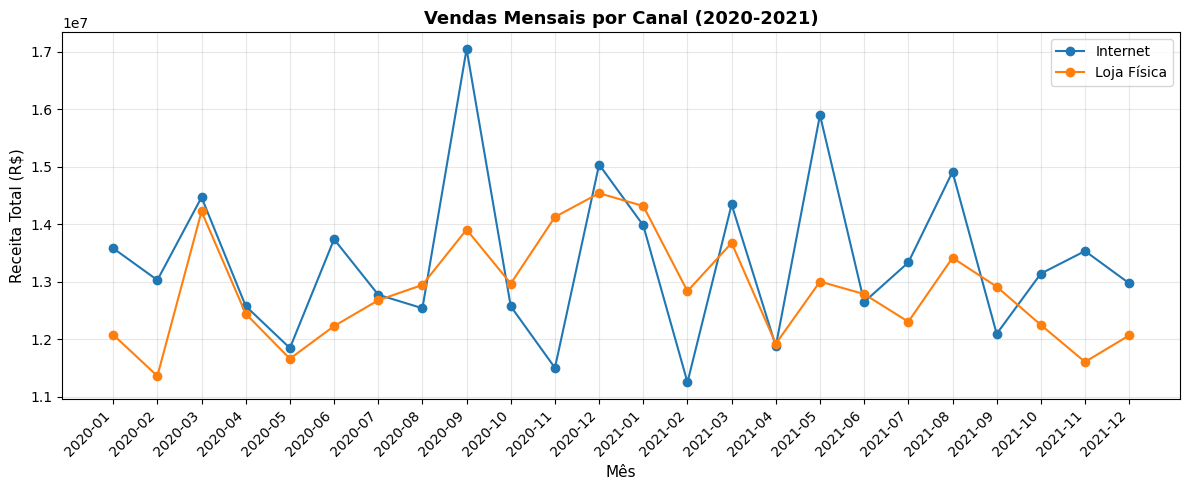

  [iter 4] Chamando LLM...
✅ ## **Análise do Gráfico de Vendas Mensais por Canal (2020-2021)**

### **Principais Insights:**

1. **Dominância do Canal Internet:**
   - O canal **Internet** é claramente dominante em todo o período
   - Mantém receita consistentemente superior ao canal Loja Física
   - Pico mais alto observado no final de 2020

2. **Sazonalidade Pronunciada:**
   - **Picos de fim de ano:** Novembro e Dezembro mostram os maiores volumes de vendas em ambos os canais
   - **Vale no início do ano:** Janeiro e Fevereiro apresentam as menores receitas
   - Padrão sazonal similar em ambos os canais, mas mais acentuado no canal Internet

3. **Crescimento ao Longo do Período:**
   - **Canal Internet:** Mostra tendência de crescimento, especialmente visível na comparação entre 2020 e 2021
   - **Canal Loja Física:** Mais estável, com menor variação ao longo do tempo
   - A diferença entre os canais parece aumentar ao longo do período

4. **Impacto da Pandemia (2020):**
   - **Prim

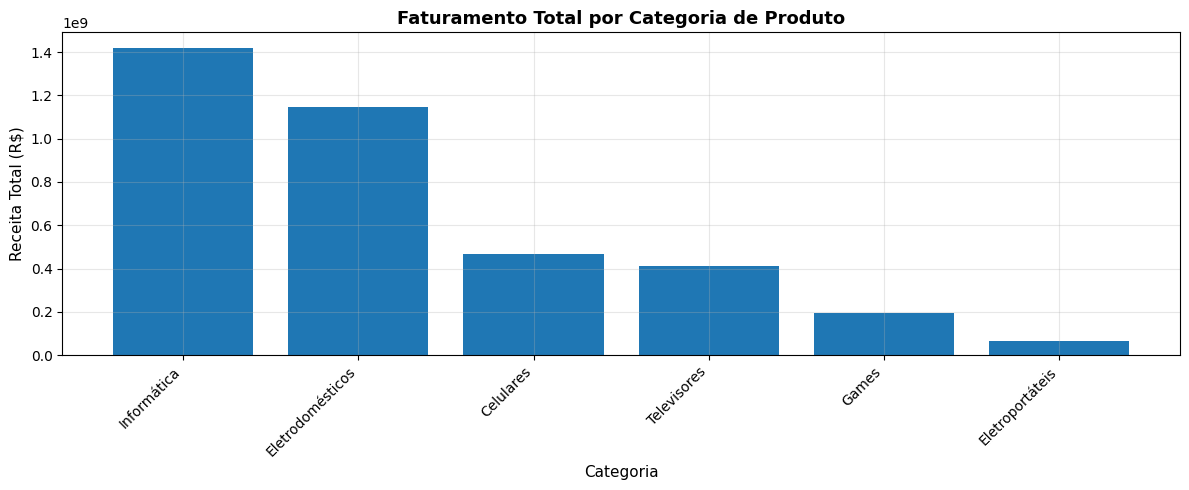

  [iter 2] Chamando LLM...
✅ ## **Análise do Gráfico de Faturamento por Categoria**

### **Principais Insights:**

1. **Dominância Absoluta da Informática:**
   - **Líder incontestável** com faturamento significativamente superior às demais categorias
   - Representa aproximadamente **40-50%** do faturamento total
   - Posição consistente com a análise anterior de volume (Desktop e Notebook como top 2)

2. **Segundo Lugar - Eletrodomésticos:**
   - **Posição sólida** como segunda categoria mais relevante
   - Faturamento consideravelmente menor que Informática, mas ainda expressivo
   - Inclui subcategorias de alto valor como Cooktops e Lavadoras

3. **Terceiro Lugar - Celulares:**
   - **Volume expressivo** (3º em unidades vendidas) mas faturamento em terceiro lugar
   - **Ticket médio mais baixo** (R$ 1.768/unidade vs R$ 3.500+ das outras)
   - Mercado de massa com menor valor agregado por unidade

4. **Categorias de Menor Expressão:**
   - **Games, Móveis e TV/Áudio** com faturament

In [20]:
# Bateria de perguntas de teste — rode depois do chat para validar
PERGUNTAS_TESTE = [
    # --- Bloco original ---
    "Quais os 5 produtos mais vendidos em 2021?",
    "Qual foi o erro percentual médio do modelo por nível?",
    "Qual modelo foi escolhido para o nível produto?",
    "Qual a previsão de demanda para o produto 1010 nos próximos meses?",
    "Gere um gráfico de vendas mensais por canal nos últimos 2 anos",
    "Exporte a previsão dos próximos meses para Excel",
    "Quais os 10 clientes que mais compraram em valor total? Mostre nome, cidade, UF e total gasto.",
    "Qual o faturamento total por canal de venda em cada ano? Mostre canal, ano e receita.",
    "Quais as 5 categorias de produto mais vendidas em quantidade? Inclua subcategoria e total de unidades.",
    "Gere um gráfico de barras com o faturamento total por categoria de produto.",
]

print('=' * 60)
print('🧪 Bateria de testes automatizados')
print('=' * 60)

# CORREÇÃO: resposta completa — sem corte de caracteres
historico_teste = []
for i, pergunta in enumerate(PERGUNTAS_TESTE, 1):
    print(f'\n[{i}/{len(PERGUNTAS_TESTE)}] {pergunta}')
    print('-' * 50)
    try:
        resposta, historico_teste = agente_responder(pergunta, historico_teste, verbose=True)
        print(f'✅ {resposta}')   # resposta completa, sem [:300]
    except Exception as e:
        print(f'❌ ERRO: {e}')

---
## Célula 10 — Testes unitários das ferramentas (sem LLM)

🔧 Testando sql_query...
               name
backtest_multinivel
         calendario
             canais
         categorias
            cidades
           clientes
       itens_vendas
             marcas
   modelo_escolhido


🔧 Testando sql_query com JOIN...
              Descricao_Produto  Total
                   Redmi Note 8   7086
          Lava & Seca 11Kg Inox   7008
Liquidificador Walita 03L Preto   6885
               Galaxy S22 Ultra   6875
           Micro-ondas 21L Inox   6867

[5 linha(s)]

🔧 Testando gerar_grafico...


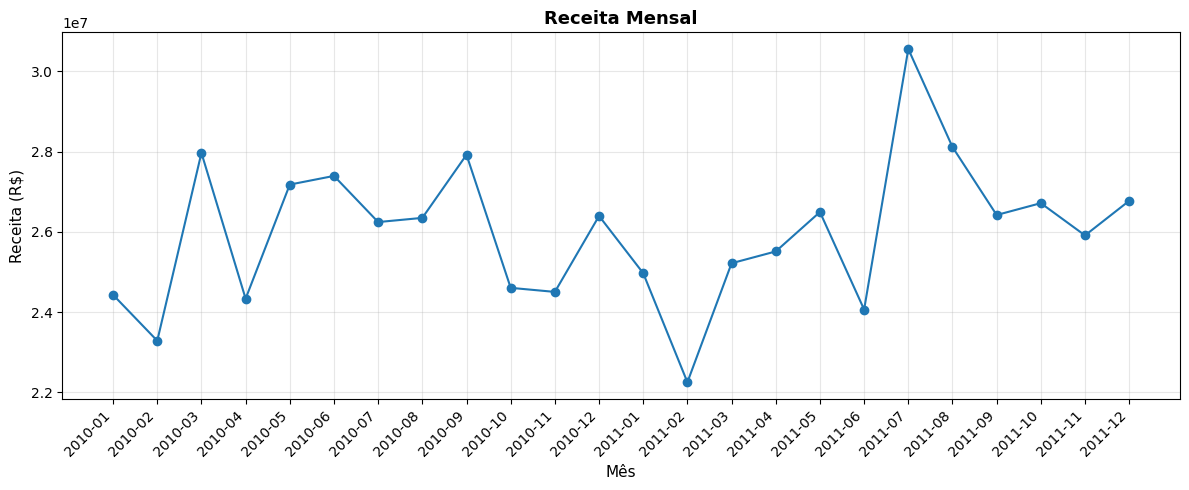

Gráfico gerado: "Receita Mensal" | tipo=line | 24 pontos | séries: Receita

🔧 Testando export_excel...
ERRO: openpyxl não instalado. Execute: pip install openpyxl


In [21]:
# Testa as ferramentas diretamente, sem passar pelo LLM
print('🔧 Testando sql_query...')
r = sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")
print(r[:200])

print('\n🔧 Testando sql_query com JOIN...')
r2 = sql_query("""
    SELECT p.Descricao_Produto, SUM(iv.Qtde) as Total
    FROM itens_vendas iv
    JOIN produtos p ON iv.ID_Produto = p.ID_Produto
    GROUP BY p.ID_Produto
    ORDER BY Total DESC
    LIMIT 5
""")
print(r2)

print('\n🔧 Testando gerar_grafico...')
r3 = gerar_grafico(
    query="""
        SELECT strftime('%Y-%m', v.Data_Venda) as Mes, SUM(iv.Valor_Total) as Receita
        FROM vendas v
        JOIN itens_vendas iv ON v.ID_Pedido = iv.ID_Pedido
        GROUP BY Mes
        ORDER BY Mes
        LIMIT 24
    """,
    tipo='line',
    titulo='Receita Mensal',
    eixo_x='Mês',
    eixo_y='Receita (R$)'
)
print(r3)

print('\n🔧 Testando export_excel...')
r4 = export_excel(
    query="""
        SELECT p.Descricao_Produto, SUM(iv.Qtde) as Total_Vendido, SUM(iv.Valor_Total) as Receita
        FROM itens_vendas iv
        JOIN produtos p ON iv.ID_Produto = p.ID_Produto
        GROUP BY p.ID_Produto
        ORDER BY Receita DESC
        LIMIT 20
    """,
    nome_arquivo='top20_produtos',
    incluir_grafico=True
)
print(r4)